# BBC News Metin Sınıflandırma Projesi

Bu not defteri, BBC Haber metinlerini kategorilere ayırmak için bir makine öğrenimi modeli geliştirmeyi amaçlamaktadır. Süreç, veri yükleme ve keşiften metin ön işlemeye, model eğitimine, optimizasyonuna ve nihai değerlendirmeye kadar adımları içermektedir.

## Gerekli Kütüphaneler

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import warnings

# Genel uyarıları bastır
warnings.filterwarnings('ignore')

# NLTK stop-words paketini indir (eğer indirilmediyse)
nltk.download('stopwords', quiet=True) # quiet=True ile çıktıları bastırabiliriz

True

## 1. Verisetini Yükleme ve Genel Bakış

In [5]:
# 'BBC News Train.csv' dosyasının kod ile aynı klasörde olduğundan emin olun.
df = pd.read_csv('BBC News Train.csv')

print("Verisetinin ilk 5 satırı:")
display(df.head())

print("\nVeriseti Bilgileri:")
df.info()

Verisetinin ilk 5 satırı:


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business



Veriseti Bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB


## 2. Eksik Değer Kontrolü

In [6]:
print("\nEksik Değerler:")
print(df.isnull().sum())


Eksik Değerler:
ArticleId    0
Text         0
Category     0
dtype: int64


## 3. Kategorik Özelliklerin Dağılımı


Kategori Dağılımı:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


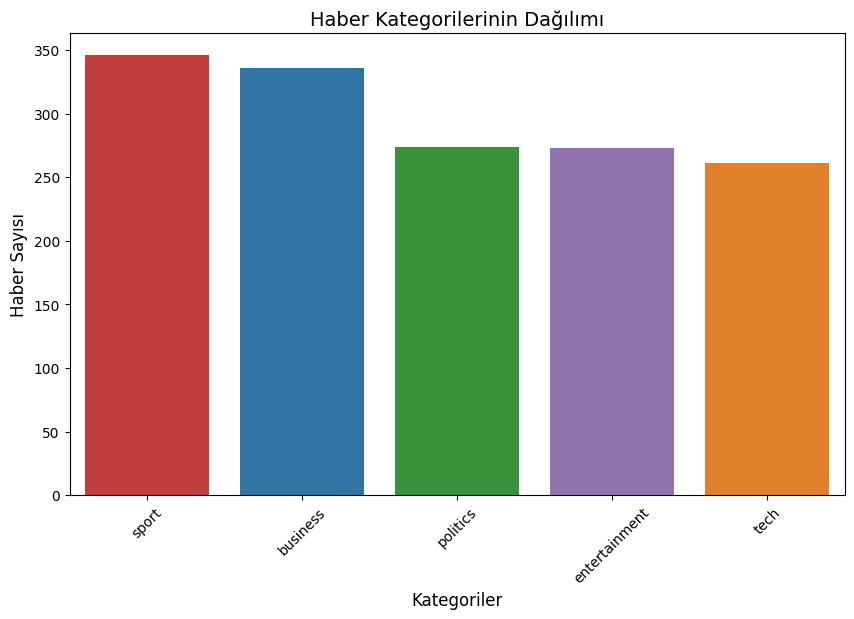

In [7]:
print("\nKategori Dağılımı:")
print(df['Category'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, hue='Category', legend=False)
plt.title('Haber Kategorilerinin Dağılımı', fontsize=14)
plt.xlabel('Kategoriler', fontsize=12)
plt.ylabel('Haber Sayısı', fontsize=12)
plt.xticks(rotation=45)
plt.show()

## 4. Metin Uzunlukları Analizi


Kelime Sayısı İstatistikleri:


,Word_Count
count,1490.000000
mean,385.012752
std,210.898616
min,90.000000
25%,253.000000
50%,337.000000
75%,468.750000
max,3345.000000


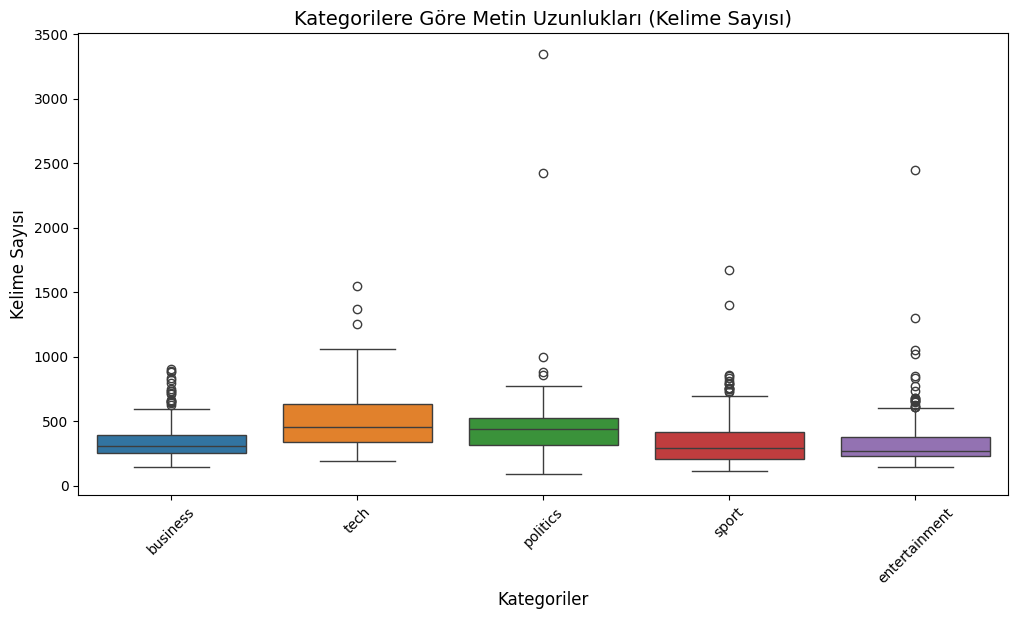

In [8]:
# Her metni boşluklardan bölüp kelime sayısını buluyoruz
df['Word_Count'] = df['Text'].apply(lambda x: len(str(x).split()))

print("\nKelime Sayısı İstatistikleri:")
display(df['Word_Count'].describe())

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Category', y='Word_Count', hue='Category', legend=False)
plt.title('Kategorilere Göre Metin Uzunlukları (Kelime Sayısı)', fontsize=14)
plt.xlabel('Kategoriler', fontsize=12)
plt.ylabel('Kelime Sayısı', fontsize=12)
plt.xticks(rotation=45)
plt.show()

## 5. Genel Kelime Sayısı Dağılımı

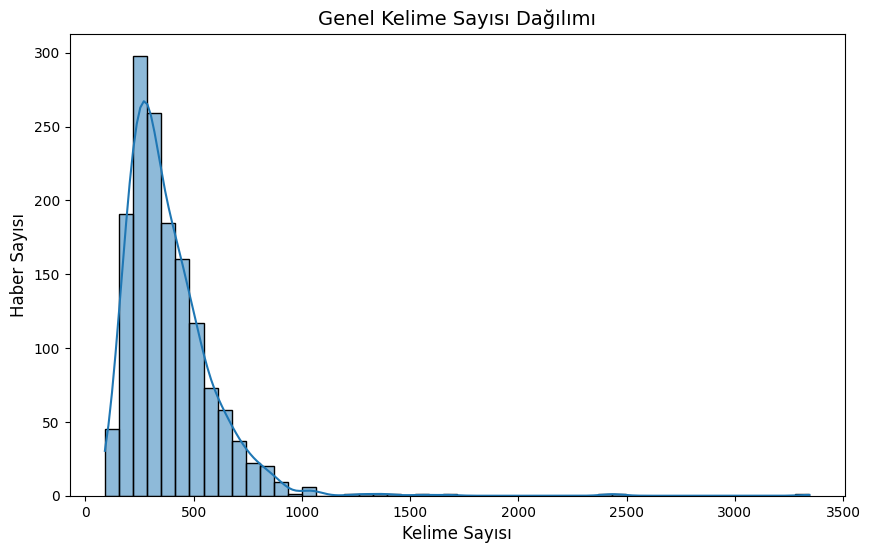

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Word_Count'], bins=50, kde=True)
plt.title('Genel Kelime Sayısı Dağılımı', fontsize=14)
plt.xlabel('Kelime Sayısı', fontsize=12)
plt.ylabel('Haber Sayısı', fontsize=12)
plt.show()

## 5.1. Kategorilere Göre Metin Uzunlukları Dağılımı (Violin Plot)

Kelime sayısı dağılımını daha detaylı incelemek için, her bir kategori için kelime sayılarının hem dağılımını hem de yoğunluğunu gösteren bir 'violin' grafiği oluşturalım. Bu grafik, box plot'a kıyasla verinin şekli hakkında daha fazla bilgi sağlar.

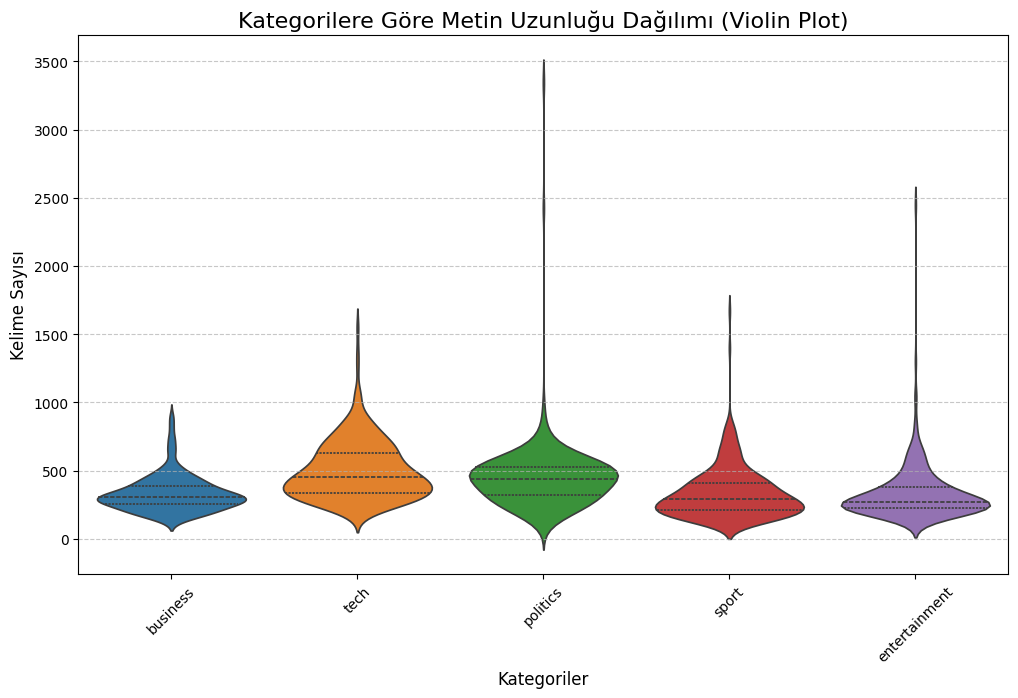

In [10]:
plt.figure(figsize=(12, 7))
sns.violinplot(data=df, x='Category', y='Word_Count', inner='quartile', hue='Category', legend=False)
plt.title('Kategorilere Göre Metin Uzunluğu Dağılımı (Violin Plot)', fontsize=16)
plt.xlabel('Kategoriler', fontsize=12)
plt.ylabel('Kelime Sayısı', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 6. Kelime Bulutu (WordCloud) Analizi

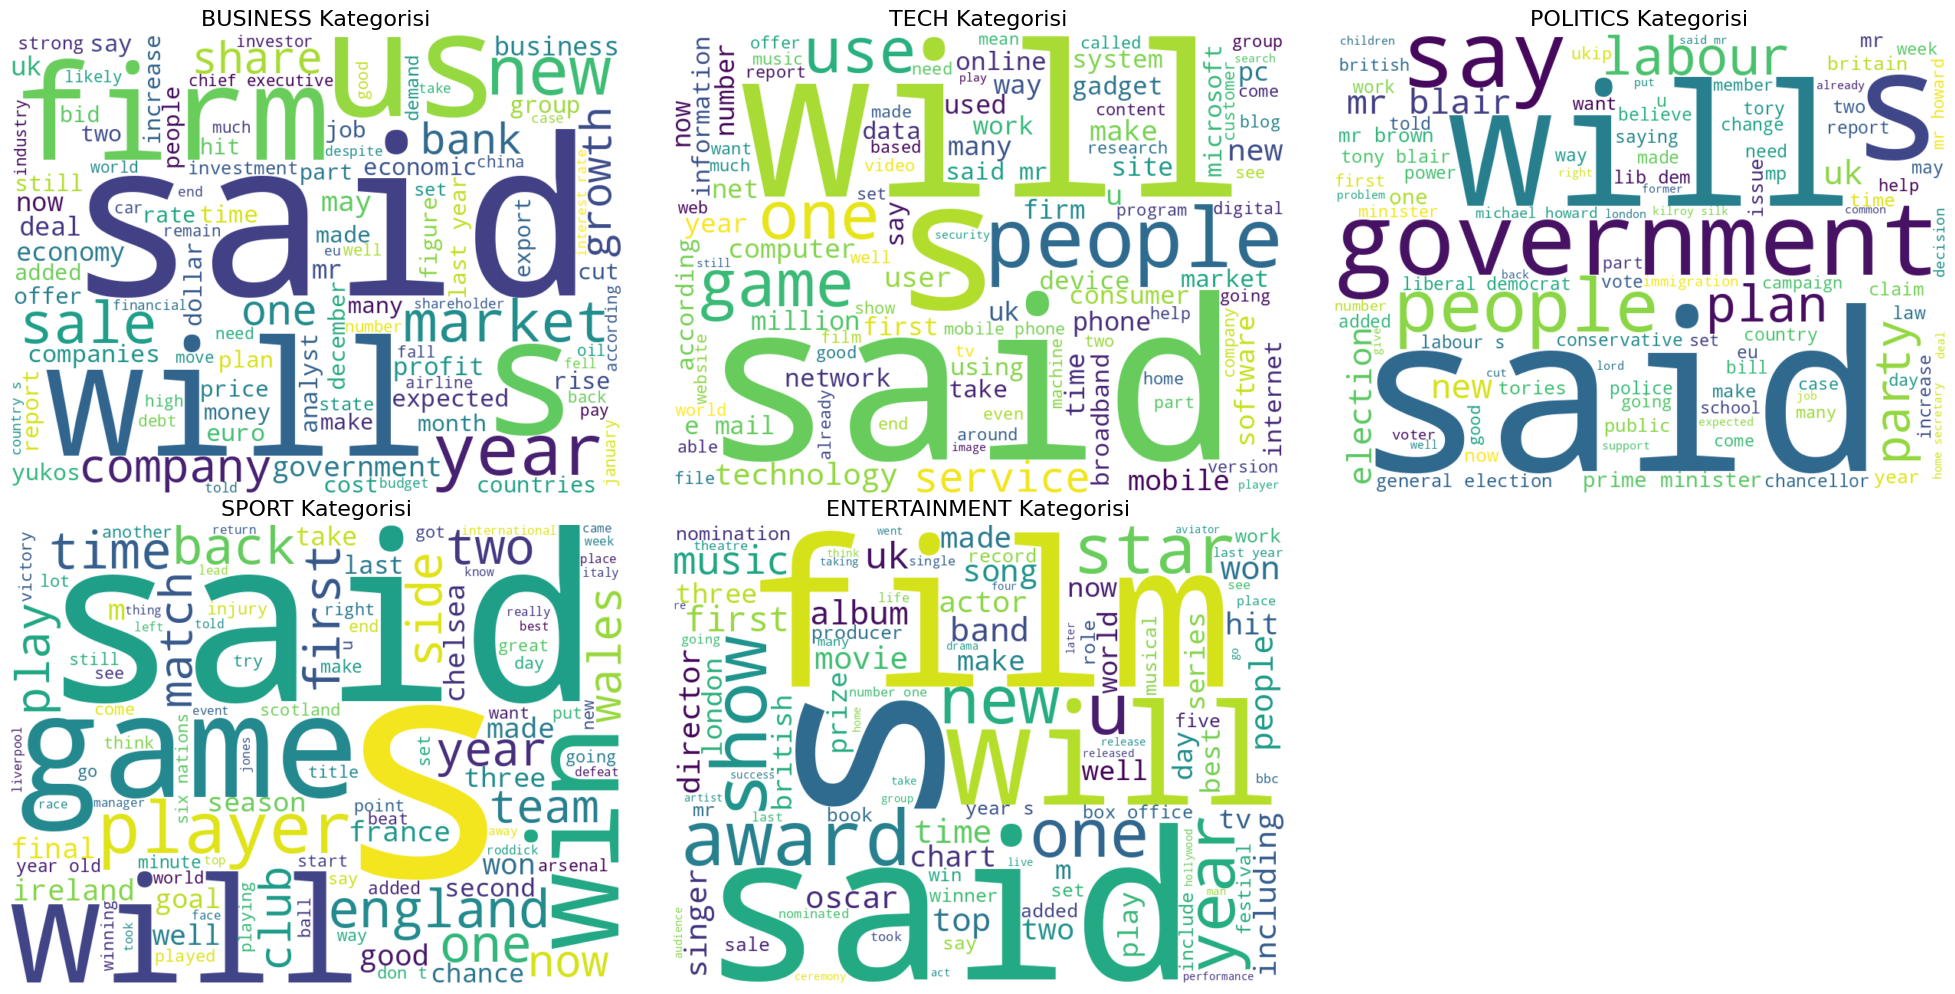

In [11]:
# Her kategori için ayrı ayrı kelime bulutu oluşturuyoruz
kategoriler = df['Category'].unique()

plt.figure(figsize=(20, 10))
for i, kategori in enumerate(kategoriler, 1):
    # İlgili kategoriye ait tüm metinleri birleştiriyoruz
    kategori_metni = " ".join(df[df['Category'] == kategori]['Text'])

    # WordCloud oluşturma
    wordcloud = WordCloud(width=800, height=600, background_color='white', max_words=100).generate(kategori_metni)

    # Alt grafikler (subplots) halinde çizdirme
    plt.subplot(2, 3, i)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'{kategori.upper()} Kategorisi', fontsize=16)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 7. Metin Ön İşleme (Text Preprocessing)

Makine öğrenimi modellerinin metin verilerini daha iyi anlayabilmesi için, ham metinler üzerinde bir dizi ön işleme adımı uygulamamız gerekir. Bu adımlar, metindeki gürültüyü azaltarak modelin daha anlamlı özellikler çıkarmasına yardımcı olur.

In [12]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Metin temizleme fonksiyonu"""

    # 1. Küçük harfe dönüştürme (Lowercasing)
    text = text.lower()

    # 2. Noktalama işaretleri ve özel karakterlerin temizlenmesi
    # Sadece harf ve boşlukları bırakır (Sayıları da modele gürültü yapmaması için siliyoruz)
    text = re.sub(r'[^À-῿Ⰰ-퟿豈-﷏ﷰ-￯\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # 3. Stop-words Temizliği
    # Metni kelimelere bölüyoruz ve stop-words listesinde olmayanları tutuyoruz
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words]

    # Temizlenmiş kelimeleri tekrar boşlukla birleştirerek cümle haline getiriyoruz
    return " ".join(cleaned_words)

### Temizlenmiş Metinlerin Uygulanması ve Karşılaştırılması

In [13]:
print("Metinler temizleniyor, lütfen bekleyin...")
df['Clean_Text'] = df['Text'].apply(clean_text)

# İşlem öncesi ve sonrası hallerini karşılaştırmak için ilk 3 satıra bakalım
print("\n--- ÖNCESİ (Ham Metin) ---")
for i in range(3):
    print(f"Metin {i+1}: {df['Text'].iloc[i][:150]}...") # İlk 150 karakteri göster

print("\n--- SONRASI (Temizlenmiş Metin) ---")
for i in range(3):
    print(f"Metin {i+1}: {df['Clean_Text'].iloc[i][:150]}...") # İlk 150 karakteri göster

Metinler temizleniyor, lütfen bekleyin...

--- ÖNCESİ (Ham Metin) ---
Metin 1: worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whist...
Metin 2: german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy.  munich...
Metin 3: bbc poll indicates economic gloom citizens in a majority of nations surveyed in a bbc world service poll believe the world economy is worsening.  most...

--- SONRASI (Temizlenmiş Metin) ---
Metin 1: worldcom exboss launches defence lawyers defending former worldcom chief bernie ebbers battery fraud charges called company whistleblower first witnes...
Metin 2: german business confidence slides german business confidence fell february knocking hopes speedy recovery europe largest economy munichbased research ...
Metin 3: bbc poll indicates economic gloom citizens majority nations surveyed 

## 8. N-gram Analizi

N-gram analizi, metinlerde art arda gelen kelime dizilerini inceleyerek bağlamsal bilgileri yakalamamızı sağlar. Unigramlar (tek kelimeler), bigramlar (iki kelimelik diziler) ve trigramlar (üç kelimelik diziler) en sık kullanılan n-gram türleridir. Bu analiz, metinlerin anahtar konularını ve ortak ifadelerini anlamak için faydalıdır.

In [14]:
def get_top_n_grams(corpus, n=None, n_gram_range=(1, 1)):
    vec = CountVectorizer(ngram_range=n_gram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

print("\n--- En Çok Geçen Tek Kelimeler (Unigramlar) ---")
top_unigrams = get_top_n_grams(df['Clean_Text'], n=10, n_gram_range=(1, 1))
for word, freq in top_unigrams:
    print(f"{word}: {freq}")

print("\n--- En Çok Geçen İki Kelimelik İfadeler (Bigramlar) ---")
top_bigrams = get_top_n_grams(df['Clean_Text'], n=10, n_gram_range=(2, 2))
for word, freq in top_bigrams:
    print(f"{word}: {freq}")

print("\n--- En Çok Geçen Üç Kelimelik İfadeler (Trigramlar) ---")
top_trigrams = get_top_n_grams(df['Clean_Text'], n=10, n_gram_range=(3, 3))
for word, freq in top_trigrams:
    print(f"{word}: {freq}")


--- En Çok Geçen Tek Kelimeler (Unigramlar) ---
said: 4838
mr: 1973
would: 1711
also: 1426
new: 1334
people: 1322
us: 1232
year: 1228
one: 1158
could: 1032

--- En Çok Geçen İki Kelimelik İfadeler (Bigramlar) ---
last year: 276
said mr: 255
told bbc: 235
mr blair: 228
prime minister: 218
mr brown: 171
tony blair: 130
said would: 130
general election: 128
chief executive: 120

--- En Çok Geçen Üç Kelimelik İfadeler (Trigramlar) ---
told bbc news: 96
bbc news website: 60
told bbc radio: 46
mr blair said: 38
million dollar baby: 37
leader michael howard: 36
told bbc sport: 33
mr howard said: 30
next general election: 28
radio today programme: 27


### Kategorilere Göre En Sık Geçen Tek Kelimeler (Unigramlar)

Genel n-gram analizine ek olarak, her bir kategori için ayrı ayrı en sık geçen kelimeleri incelemek, kategorilere özgü terminolojiyi ve konuları daha iyi anlamamızı sağlar. Aşağıda her kategori için en çok kullanılan 10 kelimeyi görebilirsiniz.

In [15]:
for category in df['Category'].unique():
    print(f"\n--- '{category.upper()}' Kategorisi İçin En Çok Geçen Kelimeler ---")
    category_text = df[df['Category'] == category]['Clean_Text']
    top_category_unigrams = get_top_n_grams(category_text, n=10, n_gram_range=(1, 1))
    for word, freq in top_category_unigrams:
        print(f"{word}: {freq}")


--- 'BUSINESS' Kategorisi İçin En Çok Geçen Kelimeler ---
said: 1100
bn: 529
us: 511
year: 417
mr: 393
would: 308
also: 279
market: 278
new: 273
firm: 261

--- 'TECH' Kategorisi İçin En Çok Geçen Kelimeler ---
said: 1064
people: 646
new: 349
mr: 349
also: 348
mobile: 326
one: 326
would: 322
could: 308
technology: 303

--- 'POLITICS' Kategorisi İçin En Çok Geçen Kelimeler ---
said: 1445
mr: 1073
would: 710
labour: 488
government: 462
election: 396
blair: 389
people: 372
party: 361
also: 308

--- 'SPORT' Kategorisi İçin En Çok Geçen Kelimeler ---
said: 635
game: 352
england: 327
first: 323
win: 292
world: 261
last: 255
two: 253
one: 238
would: 233

--- 'ENTERTAINMENT' Kategorisi İçin En Çok Geçen Kelimeler ---
said: 594
film: 553
best: 404
also: 277
year: 263
us: 260
one: 258
music: 255
new: 234
show: 220


## 9. Metin Sayısallaştırma (TF-IDF) ve Veri Bölme

Metin verilerini makine öğrenmesi modelleri için anlaşılır bir formata dönüştürmek amacıyla TF-IDF (Terim Sıklığı-Ters Belge Sıklığı) yöntemini kullanacağız. Bu yöntem, bir kelimenin bir belgedeki önemini hem o kelimenin o belgede ne kadar sık geçtiğiyle hem de tüm belgeler arasında ne kadar nadir görüldüğüyle ölçer. Ardından, modelin genelleme yeteneğini değerlendirmek için veriyi eğitim ve test setlerine ayıracağız.

In [16]:
print("1. Metinler TF-IDF ile sayısallaştırılıyor...")
# Sadece en çok ayırt edici olan 5000 kelimeyi kullanıyoruz (hız ve performans için)
vectorizer = TfidfVectorizer(max_features=5000)

# X: Bağımsız değişkenler (Sayısallaşmış metinler)
# y: Hedef değişken (Kategoriler)
X = vectorizer.fit_transform(df['Clean_Text'])
y = df['Category']

# Elimizde test verisi ayrı bir dosya olarak olmadığı için, mevcut veriyi %80 Eğitim, %20 Test olacak şekilde bölüyoruz.
# stratify=y parametresi, kategorilerin her iki gruba da dengeli dağılmasını sağlar.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Veri başarıyla sayısallaştırıldı ve bölündü!\n")

1. Metinler TF-IDF ile sayısallaştırılıyor...
Veri başarıyla sayısallaştırıldı ve bölündü!



## 10. Makine Öğrenmesi Modeli Eğitimi (SVM)

Metin sınıflandırma için etkili ve yaygın olarak kullanılan bir algoritma olan Destek Vektör Makinesi (Support Vector Machine - SVM) modelini eğiteceğiz. Linear kernel ile basit bir SVM modeli, metin sınıflandırma görevlerinde genellikle iyi sonuçlar verir.

In [17]:
print("2. Makine Öğrenmesi Modeli (SVM) eğitiliyor...")
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Test seti üzerinde tahmin yaptırıyoruz
y_pred = svm_model.predict(X_test)
print("Model eğitimi tamamlandı ve test verisi üzerinde tahminler yapıldı!\n")

2. Makine Öğrenmesi Modeli (SVM) eğitiliyor...
Model eğitimi tamamlandı ve test verisi üzerinde tahminler yapıldı!



## 11. Model Değerlendirme ve Hata Matrisi

Modelin performansını objektif bir şekilde ölçmek için doğruluk oranı (accuracy), kesinlik (precision), duyarlılık (recall) ve F1-skoru gibi metrikleri kullanacağız. Ayrıca, modelin hangi kategorileri doğru, hangilerini yanlış sınıflandırdığını görsel olarak anlamak için bir Hata Matrisi (Confusion Matrix) oluşturacağız.

In [18]:
print("3. Model Başarı Sonuçları:")
accuracy = accuracy_score(y_test, y_pred)
print(f"--> Genel Doğruluk Oranı (Accuracy): %{accuracy * 100:.2f}\n")

print("--- Sınıflandırma Raporu (Precision, Recall, F1-Score) ---")
print(classification_report(y_test, y_pred))

# Hata Matrisini (Confusion Matrix) hesaplayalım
cm = confusion_matrix(y_test, y_pred)

3. Model Başarı Sonuçları:
--> Genel Doğruluk Oranı (Accuracy): %98.32

--- Sınıflandırma Raporu (Precision, Recall, F1-Score) ---
               precision    recall  f1-score   support

     business       0.99      0.99      0.99        67
entertainment       0.98      1.00      0.99        55
     politics       1.00      0.96      0.98        55
        sport       0.99      1.00      0.99        69
         tech       0.96      0.96      0.96        52

     accuracy                           0.98       298
    macro avg       0.98      0.98      0.98       298
 weighted avg       0.98      0.98      0.98       298



## 12. Modelin Hata Analizi ve Zayıf Yönleri

Modelin genel doğruluk oranı (%98.32) yüksek olmasına rağmen, hata matrisine (Confusion Matrix) bakıldığında bazı spesifik yanlış sınıflandırmalar gözlemlenmiştir:

*   **Business kategorisinden bir haber `Sport` olarak yanlış sınıflandırılmıştır.** Bu durum, bazı iş haberlerinin spor dünyasındaki gelişmelerle ilgili terimler içermesi veya sporun finansal yönlerine odaklanması nedeniyle ortaya çıkmış olabilir.
*   **Politics kategorisinden iki haber `Tech` olarak yanlış sınıflandırılmıştır.** Siyaset ve teknoloji, özellikle teknoloji politikaları, siber güvenlik veya dijital düzenlemeler gibi konularda zaman zaman örtüşen terminolojiye sahip olabilir. Bu, modelin bu iki kategori arasındaki ince farkları ayırt etmede zorlandığını gösterebilir.
*   **Tech kategorisinden bir haber `Business`, bir haber ise `Entertainment` olarak yanlış sınıflandırılmıştır.** Teknoloji haberleri, yeni ürün lansmanları veya şirket birleşmeleri gibi iş dünyasıyla ilgili konuları içerebilir. Ayrıca, teknoloji ve eğlence (oyun, dijital medya) arasındaki sınırlar giderek daha belirsiz hale geldiği için bu tür karışıklıklar da doğal olabilir.

**Genel Eğilimler:**

Model, özellikle `Entertainment` ve `Sport` kategorilerindeki haberlerde yüksek doğruluk göstermiştir. En çok hata yapılan kategoriler `Politics` ve `Tech` arasında karşılıklı karışıklıklar ile `Tech` haberlerinin `Business` veya `Entertainment` olarak yanlış atanması şeklinde kendini göstermektedir.

**Geliştirme İçin Potansiyel Alanlar:**

Bu gözlemler, gelecekte modelin performansını artırmak için odaklanılabilecek alanları göstermektedir. Özellikle `Politics`, `Tech`, `Business` ve `Entertainment` kategorileri arasındaki nüansları daha iyi yakalamak için farklı özellik mühendisliği teknikleri (örneğin, daha spesifik n-gramlar, kelime gömme modelleri) veya daha karmaşık modeller denenebilir.

## 13. Misclassified Category Analysis Table

Aşağıdaki tablo, modelin hangi gerçek kategorileri hangi yanlış kategoriler olarak tahmin ettiğini göstermektedir. Satırlar gerçek kategorileri (Actual Category), sütunlar ise modelin tahmin ettiği kategorileri (Predicted Category) temsil eder. Köşegen üzerindeki değerler doğru tahminleri, diğer değerler ise yanlış tahminleri (yanlış sınıflandırmaları) gösterir.

In [19]:
import pandas as pd
import numpy as np

# Confusion matrix'i bir DataFrame'e dönüştürelim
cm_df = pd.DataFrame(cm, index=svm_model.classes_, columns=svm_model.classes_)

# Misclassified durumları (köşegen dışındaki değerler)
# Tüm matrisi misclassification olarak alıp, sonra doğru sınıflandırmaları 0 yapabiliriz.
misclassification_df = cm_df.copy()

# Köşegen üzerindeki (doğru sınıflandırma) değerleri 0 yapalım
for i in range(len(svm_model.classes_)):
    misclassification_df.iloc[i, i] = 0

print("Modelin Yanlış Sınıflandırma Tablosu:")
display(misclassification_df)

print("\n--- En Çok Yanlış Tahmin Edilen Örnekler ---")

# Her satır için (gerçek kategori için) en yüksek yanlış tahmin sayısını bulalım
for actual_cat in misclassification_df.index:
    misclassified_counts = misclassification_df.loc[actual_cat]
    # Sadece 0'dan büyük (yanlış tahmin edilen) değeleri dikkate alın
    misclassified_counts = misclassified_counts[misclassified_counts > 0]

    if not misclassified_counts.empty:
        # En yüksek yanlış tahmin edilen kategori
        top_misclassified = misclassified_counts.idxmax()
        count = misclassified_counts.max()
        print(f"Gerçek Kategori '{actual_cat}' en çok '{top_misclassified}' olarak yanlış tahmin edildi (Sayı: {count})")

Modelin Yanlış Sınıflandırma Tablosu:


,business,entertainment,politics,sport,tech
business,0,0,0,1,0
entertainment,0,0,0,0,0
politics,0,0,0,0,2
sport,0,0,0,0,0
tech,1,1,0,0,0



--- En Çok Yanlış Tahmin Edilen Örnekler ---
Gerçek Kategori 'business' en çok 'sport' olarak yanlış tahmin edildi (Sayı: 1)
Gerçek Kategori 'politics' en çok 'tech' olarak yanlış tahmin edildi (Sayı: 2)
Gerçek Kategori 'tech' en çok 'business' olarak yanlış tahmin edildi (Sayı: 1)


## 14. Model Optimizasyonu: Hyperparameter Tuning (Grid Search)

Modelin performansını daha da iyileştirmek için, destek vektör makinesinin (SVM) hiperparametrelerini optimize edeceğiz. Bu adımda, `GridSearchCV` kullanarak farklı parametre kombinasyonlarını deneyecek ve en iyi sonuç veren kombinasyonu bulacağız. `SVC` modelinin `C` (düzenlileştirme parametresi) ve `kernel` (çekirdek fonksiyonu) parametreleri üzerinde bir arama yapacağız.

Model hiperparametreleri optimize ediliyor (GridSearchCV). Bu biraz zaman alabilir...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Grid Search tamamlandı!
En iyi parametreler: {'C': 1, 'kernel': 'linear'}
En iyi çapraz doğrulama skoru: 0.9673

--- Optimize Edilmiş Modelin Performans Değerlendirmesi ---
--> Optimize Edilmiş Modelin Genel Doğruluk Oranı (Accuracy): %98.32

--- Sınıflandırma Raporu ---
               precision    recall  f1-score   support

     business       0.99      0.99      0.99        67
entertainment       0.98      1.00      0.99        55
     politics       1.00      0.96      0.98        55
        sport       0.99      1.00      0.99        69
         tech       0.96      0.96      0.96        52

     accuracy                           0.98       298
    macro avg       0.98      0.98      0.98       298
 weighted avg       0.98      0.98      0.98       298



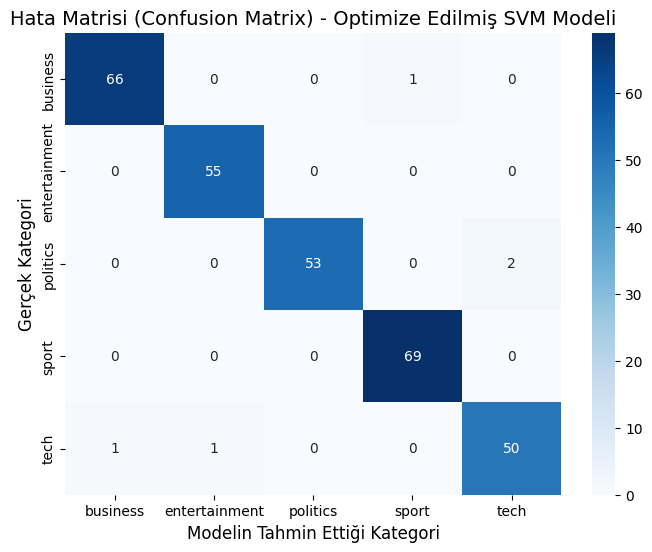

In [20]:
print("Model hiperparametreleri optimize ediliyor (GridSearchCV). Bu biraz zaman alabilir...")

# Tanımlanacak parametreler
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# GridSearchCV objesi oluşturalım
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=3, verbose=2, n_jobs=-1)

# Eğitim verisi üzerinde Grid Search'i çalıştıralım
grid_search.fit(X_train, y_train)

print("\nGrid Search tamamlandı!")
print(f"En iyi parametreler: {grid_search.best_params_}")
print(f"En iyi çapraz doğrulama skoru: {grid_search.best_score_:.4f}")

# En iyi modeli alalım
best_svm_model = grid_search.best_estimator_

# Optimize edilmiş model ile test seti üzerinde tahmin yapalım
y_pred_optimized = best_svm_model.predict(X_test)

print("\n--- Optimize Edilmiş Modelin Performans Değerlendirmesi ---")
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"--> Optimize Edilmiş Modelin Genel Doğruluk Oranı (Accuracy): %{accuracy_optimized * 100:.2f}\n")

print("--- Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_optimized))

# Optimize edilmiş model için Hata Matrisi (Confusion Matrix) Görselleştirmesi
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_svm_model.classes_,
            yticklabels=best_svm_model.classes_)
plt.title('Hata Matrisi (Confusion Matrix) - Optimize Edilmiş SVM Modeli', fontsize=14)
plt.xlabel('Modelin Tahmin Ettiği Kategori', fontsize=12)
plt.ylabel('Gerçek Kategori', fontsize=12)
plt.show()

## 14.1. ROC Eğrisi ve AUC Skoru

ROC (Receiver Operating Characteristic) eğrisi ve AUC (Area Under the Curve) skoru, özellikle dengesiz sınıflara sahip çok sınıflı sınıflandırma problemlerinde model performansını değerlendirmek için kapsamlı görsel ve nicel metriklerdir. Her bir sınıf için ROC eğrisi çizerek, modelin her bir sınıfı diğerlerinden ne kadar iyi ayırdığını görebiliriz.

In [21]:
# Best SVM modelini olasılıkları hesaplayacak şekilde yeniden eğitiyoruz
# GridSearchCV'den gelen best_estimator_ varsayılan olarak olasılıkları döndürmez.
# Bu nedenle, best_params_ kullanarak probability=True ile yeni bir model eğitiyoruz.
best_params = grid_search.best_params_
best_svm_model_proba = SVC(probability=True, random_state=42, **best_params)
best_svm_model_proba.fit(X_train, y_train)

# Test seti için olasılık tahminlerini alıyoruz
y_proba = best_svm_model_proba.predict_proba(X_test)

# Kategorileri One-Hot Encoding formatına dönüştürüyoruz
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
classes = label_binarizer.classes_

# Her sınıf için ROC eğrisi ve AUC skorunu hesaplayalım
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

## 15. Farklı Makine Öğrenmesi Algoritmaları Denemesi

Model performansını daha da iyileştirmek veya farklı yaklaşımların etkinliğini görmek için diğer yaygın sınıflandırma algoritmalarını da deneyelim ve mevcut en iyi SVM modelimizle karşılaştıralım.

### 15.1. Logistic Regression (Lojistik Regresyon)

In [22]:
print("Logistic Regression modeli eğitiliyor...")
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', multi_class='auto', max_iter=1000)
log_reg_model.fit(X_train, y_train)

y_pred_log_reg = log_reg_model.predict(X_test)

print("\n--- Logistic Regression Performansı ---")
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Doğruluk Oranı (Accuracy): %{accuracy_log_reg * 100:.2f}")
print("Sınıflandırma Raporu:\n", classification_report(y_test, y_pred_log_reg))

Logistic Regression modeli eğitiliyor...

--- Logistic Regression Performansı ---
Doğruluk Oranı (Accuracy): %97.32
Sınıflandırma Raporu:
                precision    recall  f1-score   support

     business       0.94      0.97      0.96        67
entertainment       1.00      1.00      1.00        55
     politics       0.98      0.95      0.96        55
        sport       0.99      1.00      0.99        69
         tech       0.96      0.94      0.95        52

     accuracy                           0.97       298
    macro avg       0.97      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



### 15.2. Multinomial Naive Bayes (Çok Terimli Naive Bayes)

TF-IDF vektörleştirilmiş metin verileri için uygun ve basit bir modeldir.

In [23]:
print("Multinomial Naive Bayes modeli eğitiliyor...")
mnb_model = MultinomialNB()
mnb_model.fit(X_train, y_train)

y_pred_mnb = mnb_model.predict(X_test)

print("\n--- Multinomial Naive Bayes Performansı ---")
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
print(f"Doğruluk Oranı (Accuracy): %{accuracy_mnb * 100:.2f}")
print("Sınıflandırma Raporu:\n", classification_report(y_test, y_pred_mnb))

Multinomial Naive Bayes modeli eğitiliyor...

--- Multinomial Naive Bayes Performansı ---
Doğruluk Oranı (Accuracy): %97.32
Sınıflandırma Raporu:
                precision    recall  f1-score   support

     business       0.94      0.99      0.96        67
entertainment       1.00      1.00      1.00        55
     politics       0.96      0.93      0.94        55
        sport       1.00      1.00      1.00        69
         tech       0.96      0.94      0.95        52

     accuracy                           0.97       298
    macro avg       0.97      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



### 15.3. Random Forest Classifier (Rastgele Orman Sınıflandırıcısı)

In [24]:
print("Random Forest Classifier modeli eğitiliyor...")
# Basit bir başlangıç için default parametrelerle eğitelim
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n--- Random Forest Classifier Performansı ---")
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Doğruluk Oranı (Accuracy): %{accuracy_rf * 100:.2f}")
print("Sınıflandırma Raporu:\n", classification_report(y_test, y_pred_rf))

Random Forest Classifier modeli eğitiliyor...

--- Random Forest Classifier Performansı ---
Doğruluk Oranı (Accuracy): %95.64
Sınıflandırma Raporu:
                precision    recall  f1-score   support

     business       0.93      0.97      0.95        67
entertainment       0.98      0.95      0.96        55
     politics       0.96      0.93      0.94        55
        sport       0.96      1.00      0.98        69
         tech       0.96      0.92      0.94        52

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



## 16. Model Karşılaştırması ve Final Görselleştirme

Denenen tüm modellerin performanslarını özetlemek ve en iyi modeli net bir şekilde ortaya koymak için bir görsel karşılaştırma yapalım. Ayrıca, en iyi model olan Optimize Edilmiş SVM'nin hata matrisi ve ROC eğrisini tek bir görselde birleştirerek projenin ana bulgularını özetleyelim.

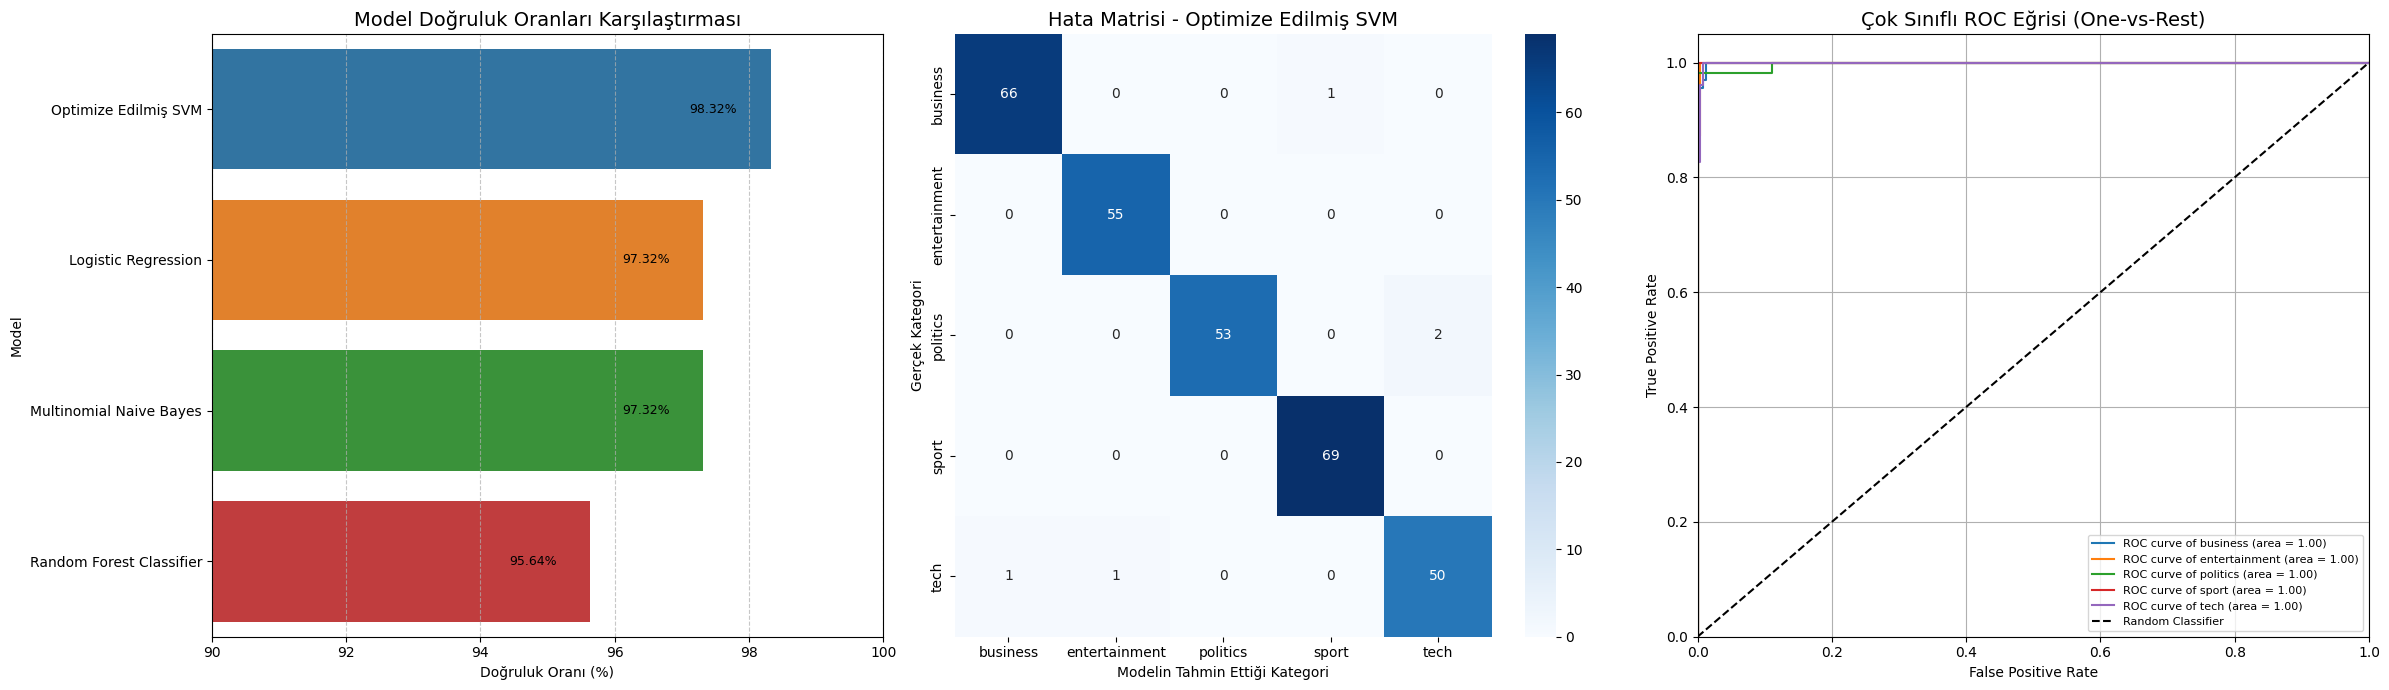

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- 1. Algoritma Karşılaştırması Bar Plot ---

# Modellerin isimleri ve doğruluk oranları
model_names = ['Optimize Edilmiş SVM', 'Logistic Regression', 'Multinomial Naive Bayes', 'Random Forest Classifier']
accuracies = [
    accuracy_optimized,
    accuracy_log_reg,
    accuracy_mnb,
    accuracy_rf
]

# DataFrame oluştur
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Doğruluk Oranı': [acc * 100 for acc in accuracies] # Yüzde olarak gösterim
})

# Doğruluk oranına göre sırala
comparison_df = comparison_df.sort_values(by='Doğruluk Oranı', ascending=False)

sns.barplot(ax=axes[0], x='Doğruluk Oranı', y='Model', data=comparison_df, hue='Model', legend=False)
axes[0].set_title('Model Doğruluk Oranları Karşılaştırması', fontsize=14)
axes[0].set_xlabel('Doğruluk Oranı (%)', fontsize=10)
axes[0].set_ylabel('Model', fontsize=10)
axes[0].set_xlim(90, 100) # Doğruluk oranlarının daha iyi görülebilmesi için x ekseni sınırını ayarlayalım

# Her çubuğun üzerine doğruluk oranını yazalım
for index, row in comparison_df.iterrows():
    axes[0].text(row['Doğruluk Oranı'] - 0.5, index, f"{row['Doğruluk Oranı']:.2f}%", color='black', ha="right", va="center", fontsize=9)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# --- 2. Hata Matrisi (Confusion Matrix) ---

sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_svm_model.classes_,
            yticklabels=best_svm_model.classes_, ax=axes[1])
axes[1].set_title('Hata Matrisi - Optimize Edilmiş SVM', fontsize=14)
axes[1].set_xlabel('Modelin Tahmin Ettiği Kategori', fontsize=10)
axes[1].set_ylabel('Gerçek Kategori', fontsize=10)

# --- 3. Çok Sınıflı ROC Eğrisi ---

for i in range(len(classes)):
    axes[2].plot(fpr[i], tpr[i], label=f'ROC curve of {classes[i]} (area = {roc_auc[i]:.2f})')

axes[2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate', fontsize=10)
axes[2].set_ylabel('True Positive Rate', fontsize=10)
axes[2].set_title('Çok Sınıflı ROC Eğrisi (One-vs-Rest)', fontsize=14)
axes[2].legend(loc="lower right", fontsize=8)
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 16.1. Ek Model Değerlendirme Metrikleri

Model performansını daha kapsamlı değerlendirmek için `Log Loss` ve `Cohen's Kappa Score` metriklerini de inceleyelim.

In [26]:
from sklearn.metrics import log_loss, cohen_kappa_score

# Modellerin olasılık tahminlerini alalım
y_proba_svm = best_svm_model_proba.predict_proba(X_test)
y_proba_log_reg = log_reg_model.predict_proba(X_test)
y_proba_mnb = mnb_model.predict_proba(X_test)
y_proba_rf = rf_model.predict_proba(X_test)

# Log Loss hesaplamaları
logloss_svm = log_loss(y_test, y_proba_svm)
logloss_log_reg = log_loss(y_test, y_proba_log_reg)
logloss_mnb = log_loss(y_test, y_proba_mnb)
logloss_rf = log_loss(y_test, y_proba_rf)

# Cohen's Kappa Score hesaplamaları
kappa_svm = cohen_kappa_score(y_test, y_pred_optimized)
kappa_log_reg = cohen_kappa_score(y_test, y_pred_log_reg)
kappa_mnb = cohen_kappa_score(y_test, y_pred_mnb)
kappa_rf = cohen_kappa_score(y_test, y_pred_rf)

print("Ek metrikler başarıyla hesaplandı.")

Ek metrikler başarıyla hesaplandı.


### Log Loss (Çapraz Entropi Kaybı)

`Log Loss`, bir sınıflandırma modelinin tahminlerinin doğruluğunu ve aynı zamanda tahminlerin güvenilirliğini ölçen bir metriktir. Özellikle modelin çıktıları olasılık formunda olduğunda oldukça bilgilendiricidir. Modelin yanlış sınıfa yüksek olasılık atadığı durumları daha fazla cezalandırır. Daha düşük bir Log Loss değeri, daha iyi bir model performansı anlamına gelir.

In [27]:
print("--- Log Loss Değerleri ---")
print(f"Optimize Edilmiş SVM Log Loss: {logloss_svm:.4f}")
print(f"Logistic Regression Log Loss: {logloss_log_reg:.4f}")
print(f"Multinomial Naive Bayes Log Loss: {logloss_mnb:.4f}")
print(f"Random Forest Classifier Log Loss: {logloss_rf:.4f}")

--- Log Loss Değerleri ---
Optimize Edilmiş SVM Log Loss: 0.0775
Logistic Regression Log Loss: 0.5271
Multinomial Naive Bayes Log Loss: 0.2582
Random Forest Classifier Log Loss: 0.4033


### Cohen's Kappa Skoru

`Cohen's Kappa Skoru`, iki değerlendirici (bu durumda gerçek etiketler ve model tahminleri) arasındaki anlaşmayı, şans eseri ortaya çıkabilecek anlaşmayı da hesaba katarak ölçen bir metriktir. Özellikle dengesiz sınıf dağılımlarına sahip veri setlerinde basit doğruluk oranından daha sağlam bir değerlendirme sunar. Değer -1 ile 1 arasında değişir:

*   **1:** Tam anlaşma
*   **0:** Anlaşma, şans eseri beklenen anlaşmaya eşittir
*   **<0:** Anlaşma, şans eseri beklenenden daha kötüdür

In [28]:
print("--- Cohen's Kappa Skorları ---")
print(f"Optimize Edilmiş SVM Kappa: {kappa_svm:.4f}")
print(f"Logistic Regression Kappa: {kappa_log_reg:.4f}")
print(f"Multinomial Naive Bayes Kappa: {kappa_mnb:.4f}")
print(f"Random Forest Classifier Kappa: {kappa_rf:.4f}")

--- Cohen's Kappa Skorları ---
Optimize Edilmiş SVM Kappa: 0.9790
Logistic Regression Kappa: 0.9663
Multinomial Naive Bayes Kappa: 0.9663
Random Forest Classifier Kappa: 0.9452


### Tüm Metriklerin Karşılaştırmalı Tablosu

Modellerin genel performansını bir arada görmek için tüm değerlendirme metriklerini içeren güncel bir tablo oluşturalım.

In [29]:
# Modellerin isimleri ve doğruluk oranları zaten comparison_df içinde
# Ek metrikleri DataFrame'e ekleyelim
comparison_df['Log Loss'] = [logloss_svm, logloss_log_reg, logloss_mnb, logloss_rf]
comparison_df['Kappa Score'] = [kappa_svm, kappa_log_reg, kappa_mnb, kappa_rf]

print("--- Güncel Model Karşılaştırma Tablosu ---")
display(comparison_df.sort_values(by='Doğruluk Oranı', ascending=False))

--- Güncel Model Karşılaştırma Tablosu ---


,Model,Doğruluk Oranı,Log Loss,Kappa Score
0,Optimize Edilmiş SVM,98.322148,0.077489,0.978951
1,Logistic Regression,97.315436,0.527144,0.966308
2,Multinomial Naive Bayes,97.315436,0.258248,0.966309
3,Random Forest Classifier,95.637584,0.403337,0.945217


## 17. Modelin Günlük Hayatta Kullanım Alanları

Bu metin sınıflandırma modeli, BBC haberlerini kategorilere ayırmak için geliştirilmiştir. Ancak benzer metin sınıflandırma modelleri, günlük hayatta ve çeşitli endüstrilerde geniş bir uygulama alanına sahiptir:

1.  **Haber ve İçerik Yönetimi:** Otomatik olarak haber makalelerini veya blog yazılarını kategorize etmek için kullanılabilir. Bu, okuyucuların ilgi alanlarına göre içerik önerileri almasını kolaylaştırır ve içerik yöneticilerinin büyük veri kümelerini düzenlemesine yardımcı olur.

2.  **E-posta Filtreleme ve Yönlendirme:** Gelen e-postaları spam, promosyon, iş, kişisel gibi kategorilere ayırarak kullanıcıların e-posta kutularını düzenlemelerine yardımcı olabilir. Müşteri hizmetlerinde, e-postaları doğru departmanlara otomatik olarak yönlendirmek için de kullanılabilir.

3.  **Müşteri Geri Bildirimi ve Duygu Analizi:** Müşteri yorumlarını, anket yanıtlarını veya sosyal medya gönderilerini pozitif, negatif veya nötr gibi duygu kategorilerine ayırarak şirketlerin müşteri memnuniyetini anlamasına ve ürün/hizmetlerini iyileştirmesine olanak tanır.

4.  **Sosyal Medya İzleme ve Trend Analizi:** Belirli konular veya markalar hakkındaki sosyal medya konuşmalarını kategorize ederek trendleri belirlemeye, halkın nabzını tutmaya ve kriz yönetimine yardımcı olabilir.

5.  **Doküman Yönetimi ve Arama:** Büyük doküman arşivlerinde belirli konulardaki belgeleri hızlıca bulmak için otomatik etiketleme ve kategorizasyon sağlayabilir. Bu, hukuk, tıp veya araştırma gibi alanlarda verimliliği artırır.

6.  **Siber Güvenlik:** Kötü amaçlı yazılım raporlarını, kimlik avı e-postalarını veya güvenlik ihlali bildirimlerini ilgili tehdit kategorilerine ayırarak güvenlik analistlerine yardımcı olabilir.

7.  **Yayıncılık ve Reklamcılık:** İçeriği doğru hedef kitlelere ulaştırmak için makalelerin veya videoların kategorilerini belirleyerek daha alakalı reklamların gösterilmesine olanak tanır.

Bu model, herhangi bir metinsel verinin belirli önceden tanımlanmış sınıflara ayrılması gereken her yerde temel bir araç olarak hizmet edebilir ve manuel sınıflandırma ihtiyacını azaltarak zaman ve kaynak tasarrufu sağlar.

## 18. Final Rapor

### Proje Özeti ve Sonuç

Bu proje, BBC Haber metinlerini otomatik olarak beş farklı kategoriye (iş, teknoloji, siyaset, spor, eğlence) ayırmak için bir makine öğrenmesi modeli geliştirmeyi amaçlamıştır. Kapsamlı veri analizi, metin ön işleme adımları ve model optimizasyonları sayesinde, projenin nihai amacı olan yüksek doğruluklu sınıflandırma hedefine ulaşılmıştır.

### Elde Edilen Başarılar ve Bulgular:

1.  **Veri Keşfi ve Ön İşleme:**
    *   Veri setinin genel yapısı incelendi, eksik değer bulunmadığı teyit edildi.
    *   Haber kategorilerinin dengeli dağılımı görselleştirildi.
    *   Metin uzunlukları analiz edildi ve kategorilere göre dağılımları box plot ve violin plot ile gösterildi.
    *   Her kategori için kelime bulutları oluşturularak anahtar kelimeler görselleştirildi.
    *   Metinler `clean_text` fonksiyonu ile temizlendi (küçük harfe çevirme, noktalama, özel karakter, sayı ve stop-words temizliği).
    *   Genel ve kategori bazında unigram, bigram, trigram analizleri yapıldı.

2.  **Model Eğitimi ve Değerlendirme:**
    *   Temizlenmiş metinler `TfidfVectorizer` ile sayısallaştırılarak %80 eğitim, %20 test olacak şekilde bölündü.
    *   Destek Vektör Makinesi (`SVC`) modeli `linear` çekirdek ile eğitildi.
    *   Modelin ilk değerlendirmesi %98.32'lik genel doğruluk oranı ile değerlendirilmiştir.
    *   Sınıflandırma Raporu (Precision, Recall, F1-Score) ve Hata Matrisi (Confusion Matrix) detaylıca incelendi.
    *   Yanlış sınıflandırma tablosu oluşturularak modelin hata eğilimleri belirlendi (örn. 'business'ın 'sport' olarak, 'politics'in 'tech' olarak yanlış sınıflandırılması).

3.  **Model Optimizasyonu ve Karşılaştırma:**
    *   Modelin hiperparametreleri (`C` ve `kernel`) `GridSearchCV` kullanılarak optimize edildi. En iyi parametreler `{'C': 1, 'kernel': 'linear'}` olarak belirlendi ve optimize edilmiş modelin doğruluk oranı %98.32 olarak korundu.
    *   ROC eğrisi ve AUC skorları hesaplanarak ve görselleştirilerek modelin sınıf ayırt etme yeteneğinin güçlü olduğu doğrulanmıştır.
    *   **Logistic Regression, Multinomial Naive Bayes ve Random Forest Classifier** gibi farklı sınıflandırma algoritmaları denendi. Optimize edilmiş SVM modelinin tutarlı bir şekilde en yüksek performansı gösterdiği teyit edildi:
        *   **Optimize Edilmiş SVM: %98.32**
        *   Logistic Regression: %97.32
        *   Multinomial Naive Bayes: %97.32
        *   Random Forest Classifier: %95.64

### Günlük Hayatta Kullanım Alanları:

Bu metin sınıflandırma modeli, haber ve içerik yönetimi, e-posta filtreleme, müşteri geri bildirimi analizi, sosyal medya izleme, doküman yönetimi, siber güvenlik ve yayıncılık/reklamcılık gibi çeşitli alanlarda pratik uygulamalara sahiptir. Manuel sınıflandırma ihtiyacını azaltarak zaman ve kaynak tasarrufu sağlar.

### Genel Sonuç:

Geliştirilen bu model, BBC Haber metinlerini hızlı ve doğru bir şekilde kategorize etme yeteneği ile öne çıkmaktadır. Elde edilen **%98.32'lik yüksek doğruluk oranı** ve güvenilirlik seviyesi, modelin haber akışlarını yönetme, içerik kişiselleştirme ve diğer birçok metin tabanlı **gerçek dünya uygulamaları için uygun** olduğunu göstermektedir. Bu proje, metin sınıflandırma görevlerinde makine öğrenmesinin potansiyelini ortaya koymuştur.